# Alibaba 2023 GPU Trace EDA

This notebook explores the Alibaba `cluster-trace-gpu-v2023` workload traces as a candidate source for realistic job and cluster assumptions. The goal is not to change the MILP formulation yet. The goal is to understand whether trace-derived groups can support a credible business/workload definition for later experiments.

Key questions:

- What does the GPU cluster inventory look like by GPU type?
- How many jobs have no GPU-type constraint versus explicit GPU specs?
- Can jobs be grouped into 4 resource/workload proxy classes using GPU constraints, GPU demand, duration, CPU, memory, QoS, and phase?
- Which trace fields can map cleanly to the current MILP schema, and which ones still require assumptions?

Source: https://github.com/alibaba/clusterdata/tree/master/cluster-trace-gpu-v2023

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "alibaba_gpu_v2023"
RAW_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
plt.style.use("default")

Matplotlib created a temporary cache directory at /var/folders/kj/srm136c14rq3h_h76tdm02700000gn/T/matplotlib-zqou90ap because the default path (/Users/juanparrado/.matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.



Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/juanparrado/.cache/fontconfig
	/Users/juanparrado/.fontconfig


## Load Trace Files

The notebook uses local CSVs under `data/raw/alibaba_gpu_v2023` when present. If they are missing, it downloads the four small 2023 CSVs directly from GitHub raw URLs.

Files used:

- `openb_node_list_gpu_node.csv`: GPU-node inventory.
- `openb_node_list_all_node.csv`: full node inventory, including non-GPU nodes.
- `openb_pod_list_default.csv`: default submitted pod/task list.
- `openb_pod_list_gpuspec33.csv`: pod/task list augmented with GPU-type constraints for about one third of GPU tasks.

In [2]:
BASE_URL = "https://raw.githubusercontent.com/alibaba/clusterdata/master/cluster-trace-gpu-v2023/csv"
TRACE_FILES = {
    "nodes_gpu": "openb_node_list_gpu_node.csv",
    "nodes_all": "openb_node_list_all_node.csv",
    "pods_default": "openb_pod_list_default.csv",
    "pods_gpuspec": "openb_pod_list_gpuspec33.csv",
}


def ensure_trace_file(filename: str) -> Path:
    path = RAW_DIR / filename
    if not path.exists():
        url = f"{BASE_URL}/{filename}"
        print(f"Downloading {url}")
        urlretrieve(url, path)
    return path


paths = {name: ensure_trace_file(filename) for name, filename in TRACE_FILES.items()}
paths

{'nodes_gpu': PosixPath('/Users/juanparrado/Documents/Quantum Master/master_thesis/data_center_scheduling/data/raw/alibaba_gpu_v2023/openb_node_list_gpu_node.csv'),
 'nodes_all': PosixPath('/Users/juanparrado/Documents/Quantum Master/master_thesis/data_center_scheduling/data/raw/alibaba_gpu_v2023/openb_node_list_all_node.csv'),
 'pods_default': PosixPath('/Users/juanparrado/Documents/Quantum Master/master_thesis/data_center_scheduling/data/raw/alibaba_gpu_v2023/openb_pod_list_default.csv'),
 'pods_gpuspec': PosixPath('/Users/juanparrado/Documents/Quantum Master/master_thesis/data_center_scheduling/data/raw/alibaba_gpu_v2023/openb_pod_list_gpuspec33.csv')}

In [3]:
nodes_gpu = pd.read_csv(paths["nodes_gpu"])
nodes_all = pd.read_csv(paths["nodes_all"])
pods_default = pd.read_csv(paths["pods_default"])
pods_gpuspec = pd.read_csv(paths["pods_gpuspec"])

print("nodes_gpu", nodes_gpu.shape)
print("nodes_all", nodes_all.shape)
print("pods_default", pods_default.shape)
print("pods_gpuspec", pods_gpuspec.shape)

display(nodes_gpu.head())
display(pods_gpuspec.head())

nodes_gpu (1213, 5)
nodes_all (1523, 5)
pods_default (8152, 11)
pods_gpuspec (8152, 11)


,sn,cpu_milli,memory_mib,gpu,model
0,openb-node-0000,64000,262144,2,P100
1,openb-node-0001,64000,262144,2,P100
2,openb-node-0002,64000,262144,2,P100
3,openb-node-0003,64000,262144,2,P100
4,openb-node-0004,64000,262144,2,P100


,name,cpu_milli,memory_mib,num_gpu,gpu_milli,gpu_spec,qos,pod_phase,creation_time,deletion_time,scheduled_time
0,openb-pod-0000,12000,16384,1,1000,NaN,LS,Running,0,12537496,0.0
1,openb-pod-0001,6000,12288,1,460,NaN,LS,Running,427061,12902960,427061.0
2,openb-pod-0002,12000,24576,1,1000,NaN,LS,Running,1558381,12902960,1558381.0
3,openb-pod-0003,6000,12288,1,460,NaN,LS,Running,2690044,12902960,2690044.0
4,openb-pod-0004,12000,16384,1,1000,NaN,LS,Running,2758084,12902960,2758084.0


## Basic Cleaning

The trace uses seconds for timestamps. We derive runtime and wait-time features. We also distinguish jobs with no GPU-type constraint from jobs that require one or more specific GPU types.

In [4]:
def normalize_gpu_spec(value: object) -> str:
    if pd.isna(value):
        return "NO_GPU_TYPE_CONSTRAINT"
    text = str(value).strip()
    if text == "" or text.lower() == "nan":
        return "NO_GPU_TYPE_CONSTRAINT"
    return text


def add_pod_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["gpu_spec_clean"] = out["gpu_spec"].map(normalize_gpu_spec)
    out["has_gpu_type_constraint"] = out["gpu_spec_clean"] != "NO_GPU_TYPE_CONSTRAINT"
    out["cpu_cores"] = out["cpu_milli"] / 1000.0
    out["memory_gib"] = out["memory_mib"] / 1024.0
    out["effective_gpu"] = out["num_gpu"] * out["gpu_milli"] / 1000.0
    out["runtime_seconds"] = out["deletion_time"] - out["scheduled_time"]
    out["wall_time_seconds"] = out["deletion_time"] - out["creation_time"]
    out["wait_seconds"] = out["scheduled_time"] - out["creation_time"]
    for column in ["runtime_seconds", "wall_time_seconds", "wait_seconds"]:
        out.loc[out[column] < 0, column] = np.nan
    out["runtime_hours"] = out["runtime_seconds"] / 3600.0
    out["wall_time_hours"] = out["wall_time_seconds"] / 3600.0
    out["wait_hours"] = out["wait_seconds"] / 3600.0
    out["duration_h_for_milp"] = np.ceil(out["runtime_hours"].clip(lower=1 / 3600)).astype("Int64")
    return out


pods = add_pod_features(pods_gpuspec)
gpu_pods = pods[pods["num_gpu"] > 0].copy()

print("All pods:", len(pods))
print("GPU pods:", len(gpu_pods))
print("GPU pods with GPU-type constraint:", int(gpu_pods["has_gpu_type_constraint"].sum()))
print("GPU pods without GPU-type constraint:", int((~gpu_pods["has_gpu_type_constraint"]).sum()))

All pods: 8152
GPU pods: 7064
GPU pods with GPU-type constraint: 2388
GPU pods without GPU-type constraint: 4676


## Cluster Inventory

This summarizes physical GPU-node availability by model. Alibaba `G1`, `G2`, and `G3` are undisclosed internal GPU codes, so they should be treated as resource classes unless we find a defensible mapping elsewhere.

,nodes,total_gpus,median_gpus_per_node
model,,,
G2,549,4392,8.0
T4,404,842,2.0
G3,39,312,8.0
P100,134,265,2.0
V100M32,30,204,8.0
V100M16,55,195,4.0
A10,2,2,1.0


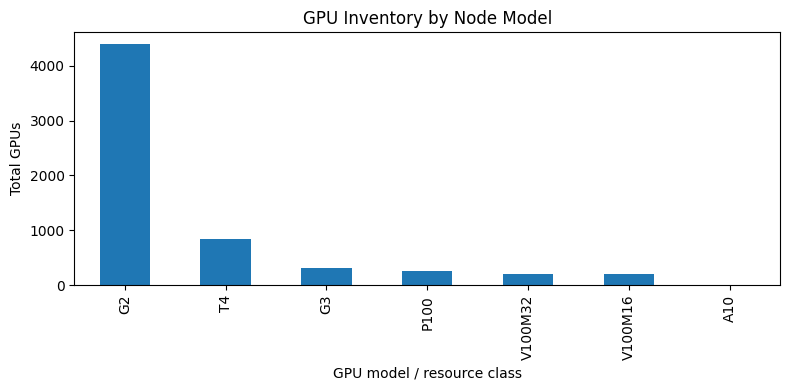

In [5]:
node_inventory = (
    nodes_gpu.groupby("model", dropna=False)
    .agg(nodes=("sn", "count"), total_gpus=("gpu", "sum"), median_gpus_per_node=("gpu", "median"))
    .sort_values("total_gpus", ascending=False)
)
display(node_inventory)

ax = node_inventory["total_gpus"].plot(kind="bar", figsize=(8, 4), title="GPU Inventory by Node Model")
ax.set_xlabel("GPU model / resource class")
ax.set_ylabel("Total GPUs")
plt.tight_layout()

## Job GPU-Spec Distribution

This table is central for deciding whether GPU spec can support cluster compatibility and workload proxy labels. The `NO_GPU_TYPE_CONSTRAINT` group is not necessarily preprocessing; it means the scheduler did not need a specific GPU type.

,jobs,median_num_gpu,mean_effective_gpu,median_cpu_cores,median_memory_gib,median_runtime_hours,median_wait_hours
gpu_spec_clean,,,,,,,
NO_GPU_TYPE_CONSTRAINT,4676,1.0,0.849311,9.810,29.801758,0.176944,0.000556
T4,1291,1.0,0.796491,9.810,29.801758,0.170556,0.000556
G2,331,1.0,1.163142,11.400,47.000000,0.220139,0.000833
P100,279,1.0,0.562151,4.000,14.900391,0.142778,0.000278
V100M16|V100M32,141,1.0,1.056738,11.400,47.000000,0.249306,0.000833
P100|V100M16|V100M32,103,1.0,1.009709,11.300,47.000000,0.170833,0.000556
G3,86,1.0,1.488372,11.350,46.500000,0.149722,0.000556
G2|P100|T4|V100M16|V100M32,39,1.0,0.854103,11.300,32.000000,0.398472,0.000833
P100|T4|V100M16|V100M32,33,1.0,1.000000,11.400,47.000000,0.456111,0.000556


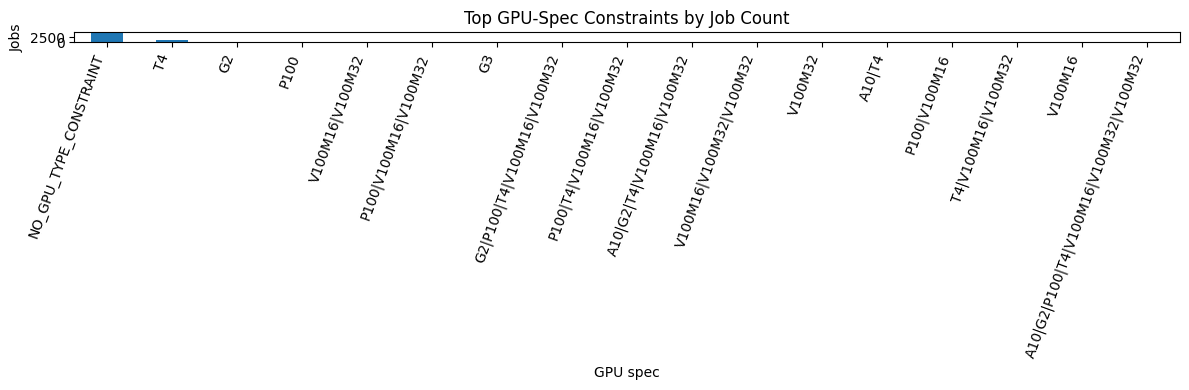

In [6]:
gpu_spec_summary = (
    gpu_pods.groupby("gpu_spec_clean")
    .agg(
        jobs=("name", "count"),
        median_num_gpu=("num_gpu", "median"),
        mean_effective_gpu=("effective_gpu", "mean"),
        median_cpu_cores=("cpu_cores", "median"),
        median_memory_gib=("memory_gib", "median"),
        median_runtime_hours=("runtime_hours", "median"),
        median_wait_hours=("wait_hours", "median"),
    )
    .sort_values("jobs", ascending=False)
)
display(gpu_spec_summary)

ax = gpu_spec_summary.head(20)["jobs"].plot(kind="bar", figsize=(12, 4), title="Top GPU-Spec Constraints by Job Count")
ax.set_xlabel("GPU spec")
ax.set_ylabel("Jobs")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()

## Numeric Feature Distributions

These distributions are candidates for calibrating the synthetic generator later. They are also candidates for clustering features.

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
num_gpu,7064.0,1.052237,0.569124,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,8.000000
gpu_milli,7064.0,809.428086,258.497299,50.000000,460.000000,650.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
effective_gpu,7064.0,0.861665,0.640809,0.050000,0.460000,0.650000,1.000000,1.000000,1.000000,1.000000,2.000000,8.000000
cpu_cores,7064.0,9.376856,7.669191,1.000000,3.152000,4.000000,11.300000,11.908000,15.700000,18.708000,24.200000,120.200000
memory_gib,7064.0,34.616062,34.309919,0.000000,5.468750,10.351562,30.517578,48.000000,57.000000,64.000000,123.000000,720.000000
runtime_hours,6203.0,8.569764,121.926891,0.001111,0.018611,0.050972,0.181944,0.639444,2.052000,4.718528,40.989167,3482.637778
wait_hours,6203.0,0.019431,0.107255,0.000000,0.000000,0.000000,0.000556,0.009722,0.038611,0.076917,0.307994,3.980556


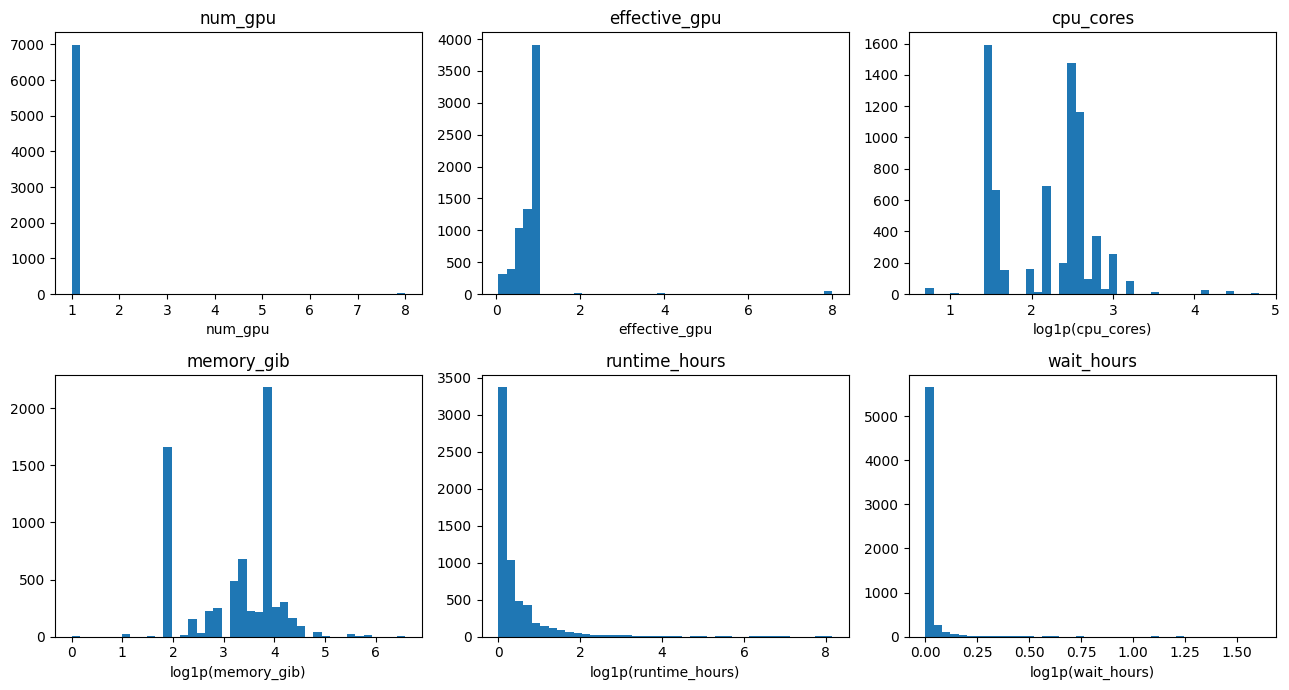

In [7]:
numeric_columns = ["num_gpu", "gpu_milli", "effective_gpu", "cpu_cores", "memory_gib", "runtime_hours", "wait_hours"]
display(gpu_pods[numeric_columns].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
plot_columns = ["num_gpu", "effective_gpu", "cpu_cores", "memory_gib", "runtime_hours", "wait_hours"]
for ax, column in zip(axes.ravel(), plot_columns):
    series = gpu_pods[column].replace([np.inf, -np.inf], np.nan).dropna()
    if column in {"runtime_hours", "wait_hours", "cpu_cores", "memory_gib"}:
        series = np.log1p(series)
        ax.set_xlabel(f"log1p({column})")
    else:
        ax.set_xlabel(column)
    ax.hist(series, bins=40)
    ax.set_title(column)
plt.tight_layout()

## Constraint-First 4-Group Proposal

This is the first pass we can explain in a thesis/business discussion. It follows the hypothesis that jobs without GPU-type constraints form one broad flexible group, while constrained jobs can be split into three more specific resource/workload proxy groups.

Proposed groups:

1. `unconstrained_flexible_batch`: no GPU-type constraint. This may be preprocessing-like, generic batch, or placement-flexible ML work.
2. `constrained_low_or_shared_gpu`: constrained jobs with fractional/shared GPU demand, latency-sensitive QoS, or lower-power GPU specs such as T4/P100.
3. `constrained_medium_gpu`: constrained jobs with moderate GPU demand and no strong high-performance signal.
4. `constrained_high_perf_or_training`: constrained jobs with high GPU demand, long runtime, or high-performance GPU specs.

These labels should be treated as proxies. Later, if business validation contradicts them, we can rename them to neutral resource classes.

In [8]:
HIGH_PERF_TOKENS = {"A10", "G3", "V100M16", "V100M32"}
LOW_OR_INFERENCE_TOKENS = {"T4", "P100"}


def spec_tokens(spec: str) -> set[str]:
    if spec == "NO_GPU_TYPE_CONSTRAINT":
        return set()
    return {item.strip() for item in spec.split("|") if item.strip()}


runtime_75 = gpu_pods["runtime_hours"].quantile(0.75)
runtime_90 = gpu_pods["runtime_hours"].quantile(0.90)


def rule_based_workload_proxy(row: pd.Series) -> str:
    tokens = spec_tokens(row["gpu_spec_clean"])
    no_constraint = row["gpu_spec_clean"] == "NO_GPU_TYPE_CONSTRAINT"
    shared_gpu = row["num_gpu"] == 1 and row["gpu_milli"] < 1000
    high_perf_spec = bool(tokens & HIGH_PERF_TOKENS)
    low_or_inference_spec = bool(tokens and tokens <= LOW_OR_INFERENCE_TOKENS)

    if no_constraint:
        return "unconstrained_flexible_batch"
    if row["num_gpu"] >= 4 or row["effective_gpu"] >= 2 or row["runtime_hours"] >= runtime_90 or (high_perf_spec and row["runtime_hours"] >= runtime_75):
        return "constrained_high_perf_or_training"
    if shared_gpu or row["qos"] == "LS" or low_or_inference_spec:
        return "constrained_low_or_shared_gpu"
    return "constrained_medium_gpu"


gpu_pods["rule_workload_proxy"] = gpu_pods.apply(rule_based_workload_proxy, axis=1)

rule_summary = (
    gpu_pods.groupby("rule_workload_proxy")
    .agg(
        jobs=("name", "count"),
        share=("name", lambda x: len(x) / len(gpu_pods)),
        median_num_gpu=("num_gpu", "median"),
        median_effective_gpu=("effective_gpu", "median"),
        median_cpu_cores=("cpu_cores", "median"),
        median_memory_gib=("memory_gib", "median"),
        median_runtime_hours=("runtime_hours", "median"),
        median_wait_hours=("wait_hours", "median"),
        gpu_type_constraint_rate=("has_gpu_type_constraint", "mean"),
    )
    .sort_values("jobs", ascending=False)
)
display(rule_summary)

display(pd.crosstab(gpu_pods["rule_workload_proxy"], gpu_pods["qos"], normalize="index"))
display(pd.crosstab(gpu_pods["rule_workload_proxy"], gpu_pods["pod_phase"], normalize="index"))

,jobs,share,median_num_gpu,median_effective_gpu,median_cpu_cores,median_memory_gib,median_runtime_hours,median_wait_hours,gpu_type_constraint_rate
rule_workload_proxy,,,,,,,,,
unconstrained_flexible_batch,4676,0.661948,1.0,1.0,9.810,29.801758,0.176944,0.000556,0.0
constrained_low_or_shared_gpu,1941,0.274773,1.0,1.0,11.300,42.000000,0.150000,0.000556,1.0
constrained_high_perf_or_training,311,0.044026,1.0,1.0,11.400,29.801758,3.184167,0.000278,1.0
constrained_medium_gpu,136,0.019253,1.0,1.0,3.152,5.468750,0.053611,0.000000,1.0


qos,BE,Burstable,Guaranteed,LS
rule_workload_proxy,,,,
constrained_high_perf_or_training,0.247588,0.073955,0.003215,0.675241
constrained_low_or_shared_gpu,0.353941,0.004122,0.000000,0.641937
constrained_medium_gpu,0.926471,0.058824,0.014706,0.000000
unconstrained_flexible_batch,0.440120,0.012831,0.000642,0.546407


pod_phase,Failed,Pending,Running,Succeeded
rule_workload_proxy,,,,
constrained_high_perf_or_training,0.196141,0.000000,0.729904,0.073955
constrained_low_or_shared_gpu,0.217414,0.139104,0.614632,0.028851
constrained_medium_gpu,0.676471,0.191176,0.110294,0.022059
unconstrained_flexible_batch,0.276732,0.120830,0.580411,0.022027


## Unsupervised Mixed-Feature Clustering

This section tries to discover 4 groups from numerical and categorical trace fields. It uses scikit-learn if available. If scikit-learn is not installed, skip this section and use the rule-based grouping above.

Features used:

- Numeric: GPU count, GPU milli, effective GPU, CPU, memory, runtime, wait time.
- Categorical: GPU spec, QoS, pod phase, GPU-type constraint flag.

Interpretation matters: clusters are statistical groups, not automatically business workload classes.

In [9]:
try:
    from sklearn.cluster import KMeans
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import silhouette_score
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False
    print("scikit-learn is not installed. Rule-based grouping is still available.")

In [10]:
if SKLEARN_AVAILABLE:
    cluster_df = gpu_pods.copy()
    for column in ["runtime_hours", "wait_hours", "cpu_cores", "memory_gib"]:
        cluster_df[f"log1p_{column}"] = np.log1p(cluster_df[column].clip(lower=0))

    numeric_features = [
        "num_gpu",
        "gpu_milli",
        "effective_gpu",
        "log1p_cpu_cores",
        "log1p_memory_gib",
        "log1p_runtime_hours",
        "log1p_wait_hours",
    ]
    categorical_features = ["gpu_spec_clean", "qos", "pod_phase", "has_gpu_type_constraint"]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )
    X = preprocessor.fit_transform(cluster_df[numeric_features + categorical_features])

    scores = {}
    for k in range(2, 8):
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X)
        sample_size = min(3000, X.shape[0])
        scores[k] = silhouette_score(X, labels, sample_size=sample_size, random_state=42)
    display(pd.Series(scores, name="silhouette_score"))

    kmeans = KMeans(n_clusters=4, random_state=42, n_init=30)
    cluster_df["kmeans_group"] = kmeans.fit_predict(X)
    gpu_pods["kmeans_group"] = cluster_df["kmeans_group"].values

    cluster_summary = (
        cluster_df.groupby("kmeans_group")
        .agg(
            jobs=("name", "count"),
            share=("name", lambda x: len(x) / len(cluster_df)),
            median_num_gpu=("num_gpu", "median"),
            median_gpu_milli=("gpu_milli", "median"),
            median_effective_gpu=("effective_gpu", "median"),
            median_cpu_cores=("cpu_cores", "median"),
            median_memory_gib=("memory_gib", "median"),
            median_runtime_hours=("runtime_hours", "median"),
            median_wait_hours=("wait_hours", "median"),
            gpu_type_constraint_rate=("has_gpu_type_constraint", "mean"),
        )
        .sort_values("jobs", ascending=False)
    )
    display(cluster_summary)
    display(pd.crosstab(cluster_df["kmeans_group"], cluster_df["gpu_spec_clean"]))
    display(pd.crosstab(cluster_df["kmeans_group"], cluster_df["rule_workload_proxy"], normalize="index"))

/opt/miniconda3/envs/quantum_py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
invalid literal for int() with base 10: ''
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/miniconda3/envs/quantum_py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 249, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_darwin()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/quantum_py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 318, in _count_physical_cores_darwin
    return int(cpu_info)
           ^^^^^^^^^^^^^


2    0.338521
3    0.352558
4    0.379737
5    0.387909
6    0.401929
7    0.363538
Name: silhouette_score, dtype: float64

,jobs,share,median_num_gpu,median_gpu_milli,median_effective_gpu,median_cpu_cores,median_memory_gib,median_runtime_hours,median_wait_hours,gpu_type_constraint_rate
kmeans_group,,,,,,,,,,
3,3684,0.521518,1.0,1000.0,1.00,11.400,47.000000,0.279167,0.000833,0.379479
2,1741,0.246461,1.0,810.0,0.81,3.152,5.468750,0.058333,0.000000,0.298105
0,1595,0.225793,1.0,460.0,0.46,8.000,29.801758,0.272222,0.000556,0.287774
1,44,0.006229,8.0,1000.0,8.00,88.000,320.000000,0.149722,0.000000,0.272727


gpu_spec_clean,A10|G2|P100|T4|V100M16|V100M32|V100M32,A10|G2|T4|V100M16|V100M32,A10|T4,G2,G2|P100|T4|V100M16|V100M32,G3,NO_GPU_TYPE_CONSTRAINT,P100,P100|T4|V100M16|V100M32,P100|V100M16,P100|V100M16|V100M32,T4,T4|V100M16|V100M32,V100M16,V100M16|V100M32,V100M16|V100M32|V100M32,V100M32
kmeans_group,,,,,,,,,,,,,,,,,
0,0,0,0,0,8,0,1136,141,0,0,0,310,0,0,0,0,0
1,0,0,0,6,0,6,32,0,0,0,0,0,0,0,0,0,0
2,2,1,2,36,6,12,1222,109,4,0,17,312,0,0,14,2,2
3,1,23,4,289,25,68,2286,29,29,4,86,669,3,3,127,20,18


rule_workload_proxy,constrained_high_perf_or_training,constrained_low_or_shared_gpu,constrained_medium_gpu,unconstrained_flexible_batch
kmeans_group,,,,
0,0.041379,0.246395,0.000000,0.712226
1,0.272727,0.000000,0.000000,0.727273
2,0.018955,0.228030,0.051120,0.701895
3,0.054289,0.312432,0.012758,0.620521


## Additional Unsupervised Clustering Alternatives

KMeans is only one view of the data. This section compares several alternatives on the same mixed-feature representation:

- `GaussianMixture`: soft probabilistic groups; useful if clusters overlap.
- `AgglomerativeClustering`: hierarchical grouping; useful for inspecting whether 4 groups are natural or forced.
- `DBSCAN`: density-based grouping; useful for detecting outliers and dense cores without forcing every job into one of four groups.
- `TruncatedSVD + KMeans`: reduces sparse one-hot categorical dimensions before clustering.

The point is not to declare one winner automatically. The point is to see whether different methods tell a consistent story about unconstrained jobs, low/shared GPU jobs, medium constrained jobs, and high-performance/long-running jobs.

In [11]:
if SKLEARN_AVAILABLE:
    from sklearn.cluster import AgglomerativeClustering, DBSCAN
    from sklearn.decomposition import TruncatedSVD
    from sklearn.mixture import GaussianMixture
    from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score


    def dense_sample(X, max_rows: int = 2500, seed: int = 42):
        rng = np.random.default_rng(seed)
        row_count = X.shape[0]
        if row_count > max_rows:
            sample_index = np.sort(rng.choice(row_count, size=max_rows, replace=False))
            return X[sample_index].toarray() if hasattr(X, "toarray") else np.asarray(X[sample_index]), sample_index
        return X.toarray() if hasattr(X, "toarray") else np.asarray(X), np.arange(row_count)


    def evaluate_labels(X_eval, labels, method_name: str) -> dict[str, object]:
        labels = np.asarray(labels)
        non_noise_mask = labels != -1
        unique_non_noise = sorted(set(labels[non_noise_mask]))
        result = {
            "method": method_name,
            "clusters_excluding_noise": len(unique_non_noise),
            "noise_share": float((labels == -1).mean()),
            "largest_cluster_share": float(pd.Series(labels).value_counts(normalize=True).iloc[0]),
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
        }
        if len(unique_non_noise) >= 2 and non_noise_mask.sum() > len(unique_non_noise):
            X_non_noise = X_eval[non_noise_mask]
            labels_non_noise = labels[non_noise_mask]
            result["silhouette"] = silhouette_score(X_non_noise, labels_non_noise)
            result["calinski_harabasz"] = calinski_harabasz_score(X_non_noise, labels_non_noise)
            result["davies_bouldin"] = davies_bouldin_score(X_non_noise, labels_non_noise)
        return result


    X_dense, sample_index = dense_sample(X, max_rows=2500)
    comparison_rows = []

    gmm = GaussianMixture(n_components=4, covariance_type="diag", random_state=42, n_init=10)
    gmm_labels = gmm.fit_predict(X_dense)
    comparison_rows.append(evaluate_labels(X_dense, gmm_labels, "GaussianMixture_diag_k4"))

    agglomerative = AgglomerativeClustering(n_clusters=4, linkage="ward")
    agglomerative_labels = agglomerative.fit_predict(X_dense)
    comparison_rows.append(evaluate_labels(X_dense, agglomerative_labels, "Agglomerative_ward_k4"))

    dbscan_grid = []
    for eps in [1.5, 2.0, 2.5, 3.0, 3.5]:
        dbscan = DBSCAN(eps=eps, min_samples=20)
        labels = dbscan.fit_predict(X_dense)
        row = evaluate_labels(X_dense, labels, f"DBSCAN_eps_{eps}")
        dbscan_grid.append(row)
    comparison_rows.extend(dbscan_grid)

    svd_components = min(20, X.shape[1] - 1)
    svd = TruncatedSVD(n_components=svd_components, random_state=42)
    X_svd = svd.fit_transform(X)
    X_svd_dense, svd_sample_index = dense_sample(X_svd, max_rows=2500)
    svd_kmeans = KMeans(n_clusters=4, random_state=42, n_init=30)
    svd_kmeans_labels = svd_kmeans.fit_predict(X_svd_dense)
    comparison_rows.append(evaluate_labels(X_svd_dense, svd_kmeans_labels, "TruncatedSVD20_KMeans_k4"))

    clustering_comparison = pd.DataFrame(comparison_rows).sort_values("silhouette", ascending=False, na_position="last")
    display(clustering_comparison)

    sampled_jobs = cluster_df.iloc[sample_index].copy()
    sampled_jobs["gmm_group"] = gmm_labels
    sampled_jobs["agglomerative_group"] = agglomerative_labels
    sampled_jobs["svd_kmeans_group"] = svd_kmeans_labels[: len(sampled_jobs)]

    for label_column in ["gmm_group", "agglomerative_group", "svd_kmeans_group"]:
        print(f"\n{label_column} summary")
        display(
            sampled_jobs.groupby(label_column)
            .agg(
                jobs=("name", "count"),
                median_num_gpu=("num_gpu", "median"),
                median_effective_gpu=("effective_gpu", "median"),
                median_cpu_cores=("cpu_cores", "median"),
                median_memory_gib=("memory_gib", "median"),
                median_runtime_hours=("runtime_hours", "median"),
                gpu_type_constraint_rate=("has_gpu_type_constraint", "mean"),
            )
            .sort_values("jobs", ascending=False)
        )
        display(pd.crosstab(sampled_jobs[label_column], sampled_jobs["rule_workload_proxy"], normalize="index"))

    EXPORT_DIR = PROJECT_ROOT / "experiments" / "outputs" / "alibaba_2023_eda"
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    clustering_comparison.to_csv(EXPORT_DIR / "clustering_method_comparison.csv", index=False)
else:
    print("Install scikit-learn to run the additional clustering alternatives.")

,method,clusters_excluding_noise,noise_share,largest_cluster_share,silhouette,calinski_harabasz,davies_bouldin
7,TruncatedSVD20_KMeans_k4,4,0.0000,0.5172,0.384817,1045.133181,0.968442
1,Agglomerative_ward_k4,4,0.0000,0.4712,0.353309,945.635782,1.117524
2,DBSCAN_eps_1.5,5,0.0744,0.3524,0.272827,770.557210,1.321443
0,GaussianMixture_diag_k4,4,0.0000,0.6544,0.121269,361.732762,2.229765
3,DBSCAN_eps_2.0,1,0.0320,0.9680,NaN,NaN,NaN
4,DBSCAN_eps_2.5,1,0.0176,0.9824,NaN,NaN,NaN
5,DBSCAN_eps_3.0,1,0.0160,0.9840,NaN,NaN,NaN
6,DBSCAN_eps_3.5,1,0.0124,0.9876,NaN,NaN,NaN



gmm_group summary


,jobs,median_num_gpu,median_effective_gpu,median_cpu_cores,median_memory_gib,median_runtime_hours,gpu_type_constraint_rate
gmm_group,,,,,,,
2,1636,1.0,1.0,8.00,29.801758,0.165833,0.000000
0,666,1.0,1.0,9.81,29.801758,0.198333,1.000000
1,184,1.0,1.0,11.30,47.000000,0.248056,1.000000
3,14,8.0,8.0,64.20,257.000000,0.136250,0.214286


rule_workload_proxy,constrained_high_perf_or_training,constrained_low_or_shared_gpu,constrained_medium_gpu,unconstrained_flexible_batch
gmm_group,,,,
0,0.093093,0.870871,0.036036,0.000000
1,0.255435,0.603261,0.141304,0.000000
2,0.000000,0.000000,0.000000,1.000000
3,0.214286,0.000000,0.000000,0.785714



agglomerative_group summary


,jobs,median_num_gpu,median_effective_gpu,median_cpu_cores,median_memory_gib,median_runtime_hours,gpu_type_constraint_rate
agglomerative_group,,,,,,,
1,1178,1.0,1.00,11.400,47.000000,0.269444,0.394737
0,703,1.0,0.47,8.000,29.801758,0.394444,0.305832
3,605,1.0,0.81,3.152,5.468750,0.055833,0.280992
2,14,8.0,8.00,64.200,257.000000,0.136250,0.214286


rule_workload_proxy,constrained_high_perf_or_training,constrained_low_or_shared_gpu,constrained_medium_gpu,unconstrained_flexible_batch
agglomerative_group,,,,
0,0.066856,0.238976,0.000000,0.694168
1,0.052632,0.326825,0.015280,0.605263
2,0.214286,0.000000,0.000000,0.785714
3,0.000000,0.228099,0.052893,0.719008



svd_kmeans_group summary


,jobs,median_num_gpu,median_effective_gpu,median_cpu_cores,median_memory_gib,median_runtime_hours,gpu_type_constraint_rate
svd_kmeans_group,,,,,,,
1,1293,1.0,1.00,11.400,47.000000,0.292083,0.385151
2,630,1.0,0.81,3.152,5.468750,0.057222,0.284127
0,563,1.0,0.46,8.000,29.801758,0.290972,0.307282
3,14,8.0,8.00,64.200,257.000000,0.136250,0.214286


rule_workload_proxy,constrained_high_perf_or_training,constrained_low_or_shared_gpu,constrained_medium_gpu,unconstrained_flexible_batch
svd_kmeans_group,,,,
0,0.044405,0.262877,0.000000,0.692718
1,0.054911,0.316319,0.013921,0.614849
2,0.020635,0.212698,0.050794,0.715873
3,0.214286,0.000000,0.000000,0.785714


## Mapping Alternatives for Our Problem

The trace is naturally GPU-scheduling data, not energy-scheduling data. A defensible integration should keep these mappings separate.

### Alternative A: Cluster-Level Energy Assignment

- Aggregate Alibaba nodes into thesis clusters by GPU resource class.
- Use job GPU-type constraints to define compatibility.
- Use trace-derived duration, GPU demand, CPU, memory, and arrival patterns.
- Add energy assumptions externally: kW/GPU by type, server overhead, PUE.

This is closest to the current MILP.

### Alternative B: Two-Stage Scheduling

1. Assign jobs to energy-aware clusters.
2. Schedule jobs within each cluster using lower-level GPU placement.

This may be more realistic, but it is more complex and should not be the first implementation.

### Alternative C: Trace-Calibrated Synthetic Generator

- Use Alibaba distributions for duration, GPU demand, compatibility, and arrivals.
- Keep generator feasible-by-construction.
- Use this for controlled Gurobi stress tests while remaining realistic.

This is likely the best bridge between research realism and solver-limit experiments.

In [12]:
candidate_mapping_table = pd.DataFrame(
    [
        {
            "trace_signal": "num_gpu, gpu_milli",
            "model_use": "GPU demand / capacity constraint",
            "confidence": "high",
        },
        {
            "trace_signal": "scheduled_time, deletion_time",
            "model_use": "job duration distribution",
            "confidence": "high if phases are filtered carefully",
        },
        {
            "trace_signal": "creation_time",
            "model_use": "arrival-time distribution",
            "confidence": "medium-high",
        },
        {
            "trace_signal": "gpu_spec",
            "model_use": "cluster compatibility / resource class",
            "confidence": "high for compatibility, low for business workload labels",
        },
        {
            "trace_signal": "qos",
            "model_use": "priority or latency-sensitivity proxy",
            "confidence": "medium",
        },
        {
            "trace_signal": "GPU model",
            "model_use": "cluster resource class and possible power assumption",
            "confidence": "medium because G1/G2/G3 are undisclosed",
        },
        {
            "trace_signal": "none",
            "model_use": "job power / energy consumption",
            "confidence": "requires external power model",
        },
    ]
)
display(candidate_mapping_table)

,trace_signal,model_use,confidence
0,"num_gpu, gpu_milli",GPU demand / capacity constraint,high
1,"scheduled_time, deletion_time",job duration distribution,high if phases are filtered carefully
2,creation_time,arrival-time distribution,medium-high
3,gpu_spec,cluster compatibility / resource class,"high for compatibility, low for business workl..."
4,qos,priority or latency-sensitivity proxy,medium
5,GPU model,cluster resource class and possible power assu...,medium because G1/G2/G3 are undisclosed
6,none,job power / energy consumption,requires external power model


## Export Optional Grouped Job Table

This exports a lightweight grouped table for later discussion. It is not yet a MILP-ready input because power assumptions and final business categories are still open.

In [13]:
EXPORT_DIR = PROJECT_ROOT / "experiments" / "outputs" / "alibaba_2023_eda"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

export_columns = [
    "name",
    "cpu_milli",
    "memory_mib",
    "num_gpu",
    "gpu_milli",
    "gpu_spec_clean",
    "qos",
    "pod_phase",
    "creation_time",
    "scheduled_time",
    "deletion_time",
    "runtime_hours",
    "wait_hours",
    "rule_workload_proxy",
]
if "kmeans_group" in gpu_pods.columns:
    export_columns.append("kmeans_group")

gpu_pods[export_columns].to_csv(EXPORT_DIR / "gpu_jobs_grouped_exploration.csv", index=False)
node_inventory.to_csv(EXPORT_DIR / "node_inventory_by_model.csv")
gpu_spec_summary.to_csv(EXPORT_DIR / "gpu_spec_summary.csv")
rule_summary.to_csv(EXPORT_DIR / "rule_group_summary.csv")

print(f"Wrote EDA outputs to {EXPORT_DIR}")

Wrote EDA outputs to /Users/juanparrado/Documents/Quantum Master/master_thesis/data_center_scheduling/experiments/outputs/alibaba_2023_eda


## Generator Calibration Outputs

This section exports empirical distributions for the synthetic instance generator. The filters keep GPU jobs with positive resource requests and runtime less than or equal to 4 hours, because very long still-running pods would otherwise dominate the duration distribution.

The exported tables include GPU compatibility proportions, duration slots, GPU-count distribution, resource quantiles, and average jobs per 24-hour window.

In [14]:
from src.instance_generator.alibaba_calibration import AlibabaCalibrationConfig, build_alibaba_generator_calibration

calibration_outputs = build_alibaba_generator_calibration(
    AlibabaCalibrationConfig(
        raw_dir=RAW_DIR,
        output_dir=EXPORT_DIR,
        max_runtime_hours=4.0,
        slot_minutes=60,
    )
)

for name, frame in calibration_outputs.items():
    print(f"{name}: {frame.shape}")

display(calibration_outputs["alibaba_generator_calibration_summary"])
display(calibration_outputs["alibaba_gpu_compatibility_distribution"].head(12))
display(calibration_outputs["alibaba_jobs_per_24h"].describe())

alibaba_generator_job_samples: (5847, 13)
alibaba_gpu_compatibility_distribution: (16, 3)
alibaba_duration_distribution_slots: (4, 3)
alibaba_gpu_count_distribution: (4, 3)
alibaba_resource_quantiles: (6, 7)
alibaba_jobs_per_24h: (52, 3)
alibaba_generator_calibration_summary: (14, 2)


,metric,value
0,raw_pods,8152.000000
1,raw_gpu_pods,7064.000000
2,generator_sample_jobs,5847.000000
3,max_runtime_hours_filter,4.000000
4,slot_minutes,60.000000
5,unrestricted_gpu_compatibility_share,0.662562
6,median_runtime_hours,0.155556
7,median_duration_slots,1.000000
8,median_gpu_count_required,1.000000
9,trace_span_days,149.325938


,gpu_type_label,jobs,probability
0,NO_GPU_TYPE_CONSTRAINT,3874,0.662562
1,T4,1070,0.183000
2,G2,283,0.048401
3,P100,209,0.035745
4,V100M16|V100M32,139,0.023773
5,P100|V100M16|V100M32,91,0.015564
6,G3,69,0.011801
7,G2|P100|T4|V100M16|V100M32,32,0.005473
8,P100|T4|V100M16|V100M32,29,0.004960
9,A10|G2|T4|V100M16|V100M32,17,0.002907


,creation_day,all_gpu_jobs,filtered_generator_jobs
count,52.000000,52.000000,52.000000
mean,110.692308,135.846154,112.442308
std,38.914959,126.292903,107.521710
min,0.000000,1.000000,0.000000
25%,110.500000,2.000000,0.000000
50%,123.500000,147.000000,126.500000
75%,136.250000,208.500000,171.500000
max,149.000000,663.000000,577.000000
